# 04 — CasADi as a Formulation Tool for MPC


CasADi changes the formulation layer:

$$
\text{dynamics, cost, constraints}
\quad \longrightarrow \quad
\text{symbolic optimization problem}.
$$

The control concept stays the same.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
from scipy.linalg import solve_discrete_are
from scipy.linalg import block_diag

np.set_printoptions(precision=4, suppress=True)

print("CasADi version:", ca.__version__)

CasADi version: 3.7.2


## Plotting helpers

The plotting code is not the topic of this notebook, so it is placed in small helper functions.

In [2]:
def plot_scalar_plan(X_value, U_value, u_max):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(X_value, "o-", label=r"$x_i$")
    ax[0].set_title("Predicted scalar state")
    ax[0].set_xlabel(r"prediction index $i$")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].step(range(len(U_value)), U_value, where="post", label=r"$u_i$")
    ax[1].axhline(u_max, linestyle=":", color="r")
    ax[1].axhline(-u_max, linestyle=":", color="r")
    ax[1].set_title("Predicted scalar input")
    ax[1].set_xlabel(r"prediction index $i$")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()


def plot_double_integrator_plan(X_value, U_value, x_max, v_max, u_max, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

    ax[0].plot(X_value[0, :], "o-", label="position")
    ax[0].axhline(x_max, linestyle=":", color="r")
    ax[0].axhline(-x_max, linestyle=":", color="r")
    ax[0].set_title("Position")
    ax[0].set_xlabel(r"prediction index $i$")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(X_value[1, :], "o-", label="velocity")
    ax[1].axhline(v_max, linestyle=":", color="r")
    ax[1].axhline(-v_max, linestyle=":", color="r")
    ax[1].set_title("Velocity")
    ax[1].set_xlabel(r"prediction index $i$")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[2].step(range(U_value.shape[1]), U_value[0, :], where="post", label="input")
    ax[2].axhline(u_max, linestyle=":", color="r")
    ax[2].axhline(-u_max, linestyle=":", color="r")
    ax[2].set_title("Input")
    ax[2].set_xlabel(r"prediction index $i$")
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_double_integrator_closed_loop(X_hist, U_hist, x_max, v_max, u_max, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

    ax[0].plot(X_hist[:, 0], "o-", label="position")
    ax[0].axhline(x_max, linestyle=":", color="r")
    ax[0].axhline(-x_max, linestyle=":", color="r")
    ax[0].set_title("Closed-loop position")
    ax[0].set_xlabel(r"time step $k$")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(X_hist[:, 1], "o-", label="velocity")
    ax[1].axhline(v_max, linestyle=":", color="r")
    ax[1].axhline(-v_max, linestyle=":", color="r")
    ax[1].set_title("Closed-loop velocity")
    ax[1].set_xlabel(r"time step $k$")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[2].step(range(len(U_hist)), U_hist[:, 0], where="post", label="input")
    ax[2].axhline(u_max, linestyle=":", color="r")
    ax[2].axhline(-u_max, linestyle=":", color="r")
    ax[2].set_title("Closed-loop input")
    ax[2].set_xlabel(r"time step $k$")
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 1) Symbolic expressions and derivatives

Start with one known scalar expression:

We first use `SX`, CasADi's simple symbolic variable type, for a scalar example.

The expressions

$$
x_{k+1}=x_k+u_k
$$

and

$$
J(x_k,u_k)=x_k^2+u_k^2+x_{k+1}^2
$$

are created symbolically. CasADi can then compute the derivative

$$
\frac{\partial J}{\partial u_k}
$$

automatically.

The numerical values $x = 2.0$ and $u = -0.7$ are only test values used to evaluate the symbolic formula.

In [3]:
x = ca.SX.sym("x")
u = ca.SX.sym("u")

x_next = x + u
J = x**2 + u**2 + x_next**2
dJ_du = ca.gradient(J, u)

J_fun = ca.Function("J_fun", [x, u], [J])
dJ_fun = ca.Function("dJ_fun", [x, u], [dJ_du])

x_value = 2.0
u_value = -0.7

print("J(x,u)        =", float(J_fun(x_value, u_value)))
print("dJ/du at x,u  =", float(dJ_fun(x_value, u_value)))

J(x,u)        = 6.180000000000001
dJ/du at x,u  = 1.2000000000000002


## 2) Scalar MPC with `Opti`

We now formulate the scalar MPC problem directly in CasADi.

The prediction model is

$$
x_{k+1}=x_k+u_k,
\qquad k=0,\ldots,N-1.
$$

The finite-horizon cost is

$$
J_N
=
\sum_{k=0}^{N-1}
\left(
q x_k^2 + r u_k^2
\right)
+
p_\infty x_N^2 .
$$

The input constraint is

$$
-u_{\max}\le u_k \le u_{\max}.
$$

`opti = ca.Opti()` creates an optimization problem.  
`opti.variable(...)` creates decision variables.  
`opti.parameter(...)` creates a value that can be changed before solving.  
`opti.subject_to(...)` adds equality or inequality constraints.

first scalar MPC input: -1.000000


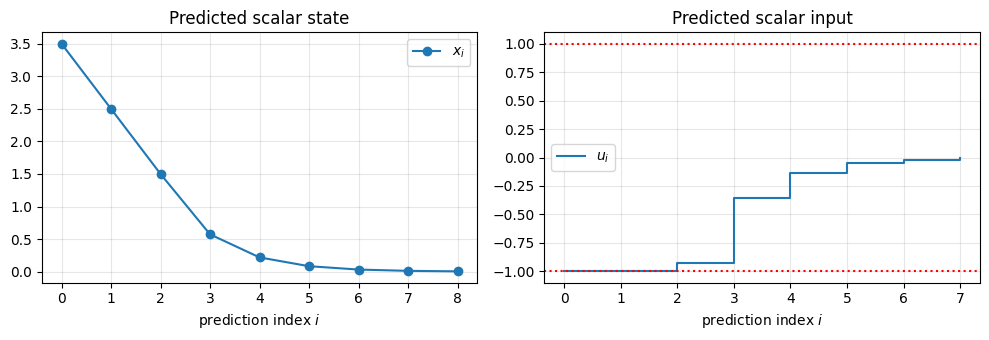

In [4]:
N_s = 8
q_s = 1.0
r_s = 1.0
u_max_s = 1.0

# Scalar terminal-cost weight from the scalar Riccati equation.
p_inf_s = 0.5 * (q_s + np.sqrt(q_s**2 + 4.0 * q_s * r_s))

# Create a CasADi optimization problem.
opti_s = ca.Opti()

# Decision variables: predicted states x_0,...,x_N and inputs u_0,...,u_{N-1}.
X_s = opti_s.variable(N_s + 1)
U_s = opti_s.variable(N_s)

# Parameter: measured initial state. We can change this value before solving.
x0_s = opti_s.parameter()

# Initial condition constraint: the prediction starts at the measured state.
opti_s.subject_to(X_s[0] == x0_s)

# Cost function: sum of stage costs and terminal cost.
J_s = 0
for k in range(N_s):
    # Dynamics constraint: x_{k+1} = x_k + u_k.
    opti_s.subject_to(X_s[k + 1] == X_s[k] + U_s[k])

    # Input constraint: -u_max <= u_k <= u_max.
    opti_s.subject_to(opti_s.bounded(-u_max_s, U_s[k], u_max_s))

    # Stage cost.
    J_s += q_s * X_s[k]**2 + r_s * U_s[k]**2

# Terminal cost.
J_s += p_inf_s * X_s[N_s]**2

# Tell CasADi which expression shall be minimized.
opti_s.minimize(J_s)

# Use IPOPT as the numerical solver.
opti_s.solver("ipopt", {"print_time": False}, {"print_level": 0, "sb": "yes"})

# Set the measured initial state and solve.
opti_s.set_value(x0_s, 3.5)
sol_s = opti_s.solve()

X_s_value = np.array(sol_s.value(X_s)).reshape(-1)
U_s_value = np.array(sol_s.value(U_s)).reshape(-1)

print(f"first scalar MPC input: {U_s_value[0]:+.6f}")
plot_scalar_plan(X_s_value, U_s_value, u_max_s)

## 3) Double-integrator benchmark

Now use the Chapter 3 benchmark again:

$$
x_{k+1}=Ax_k+Bu_k,
\qquad
x=\begin{bmatrix}p\\v\end{bmatrix}.
$$

In [5]:
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.0],
              [1.0]])

Q = np.diag([4.0, 1.0])
R = np.array([[0.2]])
P_inf = solve_discrete_are(A, B, Q, R)

A_ca = ca.DM(A)
B_ca = ca.DM(B)
Q_ca = ca.DM(Q)
R_ca = ca.DM(R)
P_ca = ca.DM(P_inf)

N = 10
nx = 2
nu = 1

x_max = 4.8
v_max = 2.5
u_max = 0.8

print("P_inf =")
print(P_inf)

P_inf =
[[9.0385 5.1926]
 [5.1926 6.5407]]


### Dense and sparse MPC formulations

In Chapter 3 we mainly used the condensed dense formulation. There, the predicted states are eliminated with

$$
X=\Phi x_0+\Gamma U,
$$

and the optimizer only sees the stacked input vector \(U\).

CasADi also makes it natural to write the sparse, or full-space, formulation. In this form, both \(X\) and \(U\) are decision variables:

$$
\min_{X,U}
\quad
X_{\mathrm{stage}}^\top \bar Q X_{\mathrm{stage}}
+
U^\top \bar R U
+
x_N^\top P_f x_N
$$

subject to

$$
x_0=x_{\mathrm{meas}},
$$

$$
x_{k+1}=Ax_k+Bu_k,
$$

and the box constraints on all predicted states and inputs.

This is the same MPC problem, but written differently: the dynamics are explicit equality constraints instead of being hidden inside $\Phi$ and $\Gamma$.

## 4) Double-integrator MPC in CasADi

We now formulate the same double-integrator MPC problem in CasADi.

The state is

$$
x_k =
\begin{bmatrix}
p_k\\
v_k
\end{bmatrix},
$$

where $p_k$ is position and $v_k$ is velocity.

The prediction model is

$$
x_{k+1}=Ax_k+Bu_k.
$$

The finite-horizon cost is

$$
J_N =
\sum_{k=0}^{N-1}
\left(
x_k^\top Q x_k + u_k^\top R u_k
\right)
+
x_N^\top P_f x_N .
$$

The box constraints are

$$
-u_{\max}\le u_k\le u_{\max},
$$

and

$$
-p_{\max}\le p_k\le p_{\max},
\qquad
-v_{\max}\le v_k\le v_{\max}.
$$

In CasADi, we can impose these bounds directly on the full matrices `X` and `U`.  

In [6]:
opti = ca.Opti()

# Decision variables:
# X contains x_0, ..., x_N as columns.
# U contains u_0, ..., u_{N-1} as columns.
X = opti.variable(nx, N + 1)
U = opti.variable(nu, N)

# Parameter: measured initial state.
x0_par = opti.parameter(nx)

# Initial condition: x_0 = x_meas
opti.subject_to(X[:, 0] == x0_par)

# Dynamics for all prediction steps:
# X[:, 1:] contains x_1, ..., x_N
# X[:, :-1] contains x_0, ..., x_{N-1}
opti.subject_to(
    X[:, 1:] == ca.mtimes(A_ca, X[:, :-1]) + ca.mtimes(B_ca, U)
)

# Box constraints on all predicted inputs.
opti.subject_to(opti.bounded(-u_max, U, u_max))

# Box constraints on all predicted states.
# State vector: x_k = [p_k, v_k]^T
p_max = x_max   # better: rename x_max to p_max in the notebook

x_lower = ca.repmat(ca.DM([-p_max, -v_max]), 1, N + 1)
x_upper = ca.repmat(ca.DM([ p_max,  v_max]), 1, N + 1)

opti.subject_to(opti.bounded(x_lower, X, x_upper))

# Cost in stacked form.
# X_stage contains x_0, ..., x_{N-1}
X_stage = X[:, :-1]
x_N = X[:, N]

X_stage_flat = ca.reshape(X_stage, nx * N, 1)
U_flat = ca.reshape(U, nu * N, 1)

Q_bar_stage = ca.diagcat(*([Q_ca] * N))
R_bar = ca.diagcat(*([R_ca] * N))

J = ca.mtimes([X_stage_flat.T, Q_bar_stage, X_stage_flat])
J += ca.mtimes([U_flat.T, R_bar, U_flat])
J += ca.mtimes([x_N.T, P_ca, x_N])

opti.minimize(J)

# IPOPT is a generic nonlinear solver.
# We use it here because the Opti formulation is readable.
opti.solver("ipopt", {"print_time": False}, {"print_level": 0, "sb": "yes"})

## 5) Solve one MPC step

The solver object is fixed. The current state enters through the parameter $x_{\mathrm{meas}}$.

first CasADi MPC input: -0.800000


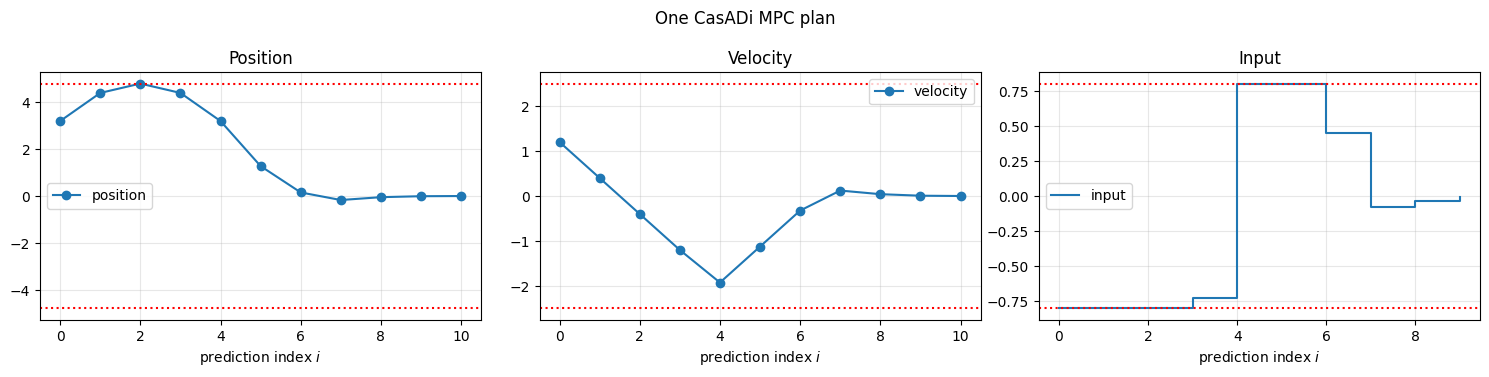

In [7]:
def solve_double_integrator_once(x0_value):
    # Set the measured state, solve the Opti problem, and return the plan.
    opti.set_value(x0_par, np.array(x0_value, dtype=float).reshape(nx))
    sol = opti.solve()

    # Keep the same shapes as in the CasADi decision variables:
    # X has shape (nx, N+1), U has shape (nu, N).
    X_value = np.array(sol.value(X)).reshape(nx, N + 1)
    U_value = np.array(sol.value(U)).reshape(nu, N)

    # Warm start for the next call.
    opti.set_initial(X, X_value)
    opti.set_initial(U, U_value)

    return X_value, U_value, sol


x0_value = np.array([3.2, 1.2])
X_value, U_value, sol = solve_double_integrator_once(x0_value)

print(f"first CasADi MPC input: {U_value[0, 0]:+.6f}")
plot_double_integrator_plan(X_value, U_value, x_max, v_max, u_max, "One CasADi MPC plan")

## 6) Receding horizon with CasADi

The closed-loop logic is the same as before:

$$
\text{solve} \;\rightarrow\; \text{apply } u_0^\star \;\rightarrow\; \text{simulate one step} \;\rightarrow\; \text{solve again}.
$$

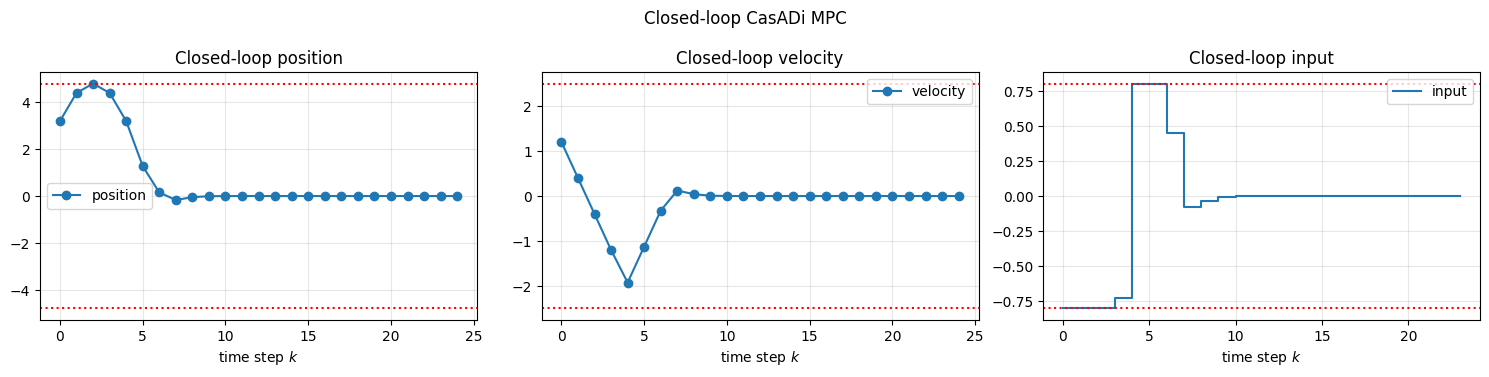

In [8]:
sim_steps = 24
X_hist = np.zeros((sim_steps + 1, nx))
U_hist = np.zeros((sim_steps, nu))

X_hist[0] = np.array([3.2, 1.2]) # initial state

for k in range(sim_steps):
    X_plan, U_plan, _ = solve_double_integrator_once(X_hist[k])

    # Receding-horizon principle: apply only the first input.
    U_hist[k] = U_plan[:, 0]
    # Simulate one step forward in time using the system dynamics.
    X_hist[k + 1] = A @ X_hist[k] + B @ U_hist[k]

plot_double_integrator_closed_loop(X_hist, U_hist, x_max, v_max, u_max, "Closed-loop CasADi MPC")

## 7) Soft position constraint

The previous MPC used the hard position constraint

$$
-p_{\max}\le p_k \le p_{\max}.
$$

If the measured initial state already violates this bound, the hard problem is infeasible.

We therefore soften only the position constraint:

$$
-p_{\max}-\varepsilon_k
\le p_k \le
p_{\max}+\varepsilon_k,
\qquad
\varepsilon_k\ge 0.
$$

The slack is penalized by

$$
J_{\mathrm{soft}}
=
J
+
\rho \sum_{k=0}^{N}\varepsilon_k^2 .
$$

The input constraint and the velocity constraint remain hard.

In [9]:
rho = 1000.0

opti_soft = ca.Opti()

X_soft_var = opti_soft.variable(nx, N + 1)
U_soft_var = opti_soft.variable(nu, N)
eps = opti_soft.variable(1, N + 1)

x0_soft_par = opti_soft.parameter(nx)

# Initial condition and dynamics
opti_soft.subject_to(X_soft_var[:, 0] == x0_soft_par)
opti_soft.subject_to(
    X_soft_var[:, 1:] == ca.mtimes(A_ca, X_soft_var[:, :-1])
    + ca.mtimes(B_ca, U_soft_var)
)

# Hard constraints
opti_soft.subject_to(opti_soft.bounded(-u_max, U_soft_var, u_max))
opti_soft.subject_to(opti_soft.bounded(-v_max, X_soft_var[1, :], v_max))

# Soft position constraint
opti_soft.subject_to(eps >= 0)
opti_soft.subject_to(X_soft_var[0, :] <=  p_max + eps)
opti_soft.subject_to(X_soft_var[0, :] >= -p_max - eps)

# Same MPC cost as before
X_stage_soft = X_soft_var[:, :-1]
x_N_soft = X_soft_var[:, N]

X_stage_soft_flat = ca.reshape(X_stage_soft, nx * N, 1)
U_soft_flat = ca.reshape(U_soft_var, nu * N, 1)

J_soft = ca.mtimes([X_stage_soft_flat.T, Q_bar_stage, X_stage_soft_flat])
J_soft += ca.mtimes([U_soft_flat.T, R_bar, U_soft_flat])
J_soft += ca.mtimes([x_N_soft.T, P_ca, x_N_soft])
J_soft += rho * ca.sumsqr(eps)

opti_soft.minimize(J_soft)
opti_soft.solver("ipopt", {"print_time": False}, {"print_level": 0, "sb": "yes"})

initial slack: 0.5000
maximum slack over all MPC solves: 0.5000


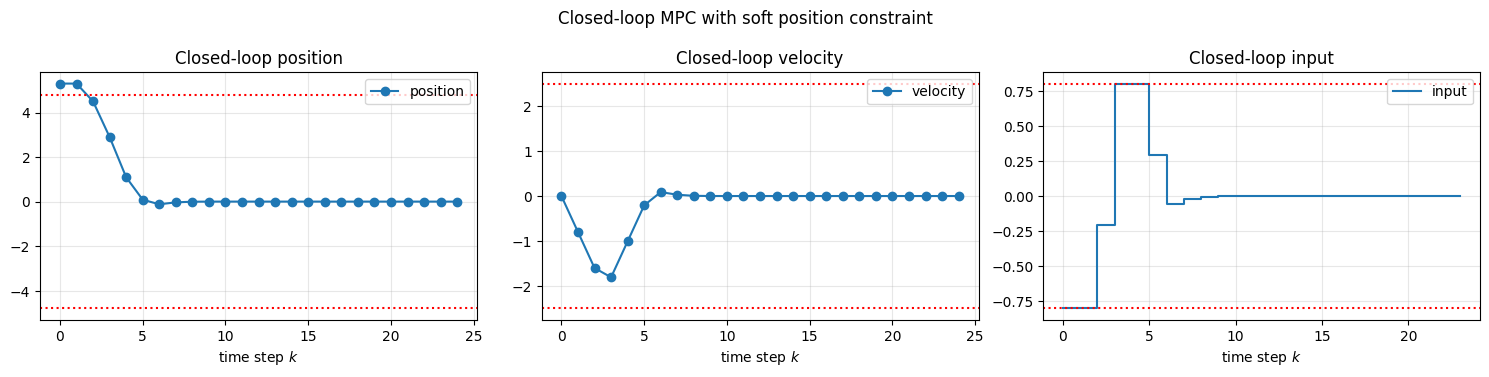

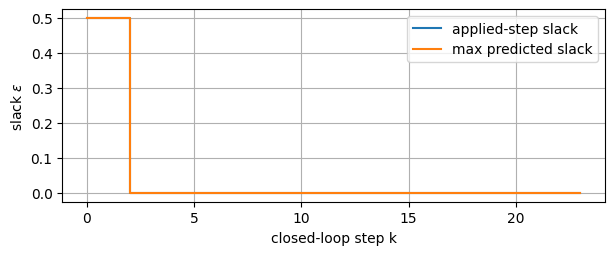

In [10]:
# Closed-loop soft-constrained MPC simulation.
# Softened: position constraint.
# Still hard: input and velocity constraints.

sim_steps_soft = 24

x0_soft = np.array([p_max + 0.5, 0.0])

# Important: velocity is still hard. If this is violated initially,
# the soft-position MPC problem is infeasible.
if abs(x0_soft[1]) > v_max:
    raise ValueError("Initial velocity violates the hard velocity constraint.")

X_soft_hist = np.zeros((sim_steps_soft + 1, nx))
U_soft_hist = np.zeros((sim_steps_soft, nu))
eps0_hist = np.zeros(sim_steps_soft)
epsmax_hist = np.zeros(sim_steps_soft)

X_soft_hist[0] = x0_soft

for k in range(sim_steps_soft):
    opti_soft.set_value(x0_soft_par, X_soft_hist[k])

    sol_soft = opti_soft.solve()

    X_plan_soft = np.array(sol_soft.value(X_soft_var)).reshape(nx, N + 1)
    U_plan_soft = np.array(sol_soft.value(U_soft_var)).reshape(nu, N)
    eps_plan = np.array(sol_soft.value(eps)).reshape(-1)

    # Receding-horizon principle: apply only the first input.
    u0 = U_plan_soft[:, 0]

    U_soft_hist[k] = u0
    X_soft_hist[k + 1] = A @ X_soft_hist[k] + B @ u0

    eps0_hist[k] = eps_plan[0]
    epsmax_hist[k] = np.max(eps_plan)

    # Warm start for the next solve.
    opti_soft.set_initial(X_soft_var, X_plan_soft)
    opti_soft.set_initial(U_soft_var, U_plan_soft)
    opti_soft.set_initial(eps, eps_plan.reshape(1, N + 1))

print(f"initial slack: {eps0_hist[0]:.4f}")
print(f"maximum slack over all MPC solves: {np.max(epsmax_hist):.4f}")

plot_double_integrator_closed_loop(
    X_soft_hist,
    U_soft_hist,
    p_max,
    v_max,
    u_max,
    "Closed-loop MPC with soft position constraint",
)

plt.figure(figsize=(7, 2.5))
plt.step(range(sim_steps_soft), eps0_hist, where="post", label="applied-step slack")
plt.step(range(sim_steps_soft), epsmax_hist, where="post", label="max predicted slack")
plt.xlabel("closed-loop step k")
plt.ylabel("slack $\\varepsilon$")
plt.grid(True)
plt.legend()
plt.show()